In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [31]:
iris = load_iris()
print(iris.keys())

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target 

print(df.head())



dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [21]:
label_counts = df['target'].value_counts()
print("Number of target of each type:")
print(label_counts)

Number of target of each type:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [30]:
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [29]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC()
}

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted'),
        'Confusion Matrix': confusion_matrix(y_test, y_pred)
    }


In [24]:
results_no_reduction = {name: evaluate_model(model, X_train_std, X_test_std, y_train, y_test) for name, model in models.items()}


In [25]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

results_pca = {name: evaluate_model(model, X_train_pca, X_test_pca, y_train, y_test) for name, model in models.items()}


In [26]:
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_std, y_train)
X_test_lda = lda.transform(X_test_std)

results_lda = {name: evaluate_model(model, X_train_lda, X_test_lda, y_train, y_test) for name, model in models.items()}


In [27]:
def print_results(results, title):
    print(f"\n{title}\n" + "-"*50)
    for model, metrics in results.items():
        print(f"\nModel: {model}")
        for metric, value in metrics.items():
            if metric == 'Confusion Matrix':
                print(f"{metric}:\n{value}")
            else:
                print(f"{metric}: {value:.4f}")

print_results(results_no_reduction, "Results without Dimensionality Reduction")
print_results(results_pca, "Results with PCA")
print_results(results_lda, "Results with LDA")



Results without Dimensionality Reduction
--------------------------------------------------

Model: Logistic Regression
Accuracy: 0.9111
Precision: 0.9155
Recall: 0.9111
F1-Score: 0.9107
Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

Model: Decision Tree
Accuracy: 0.9556
Precision: 0.9608
Recall: 0.9556
F1-Score: 0.9554
Confusion Matrix:
[[15  0  0]
 [ 0 15  0]
 [ 0  2 13]]

Model: Random Forest
Accuracy: 0.8889
Precision: 0.8981
Recall: 0.8889
F1-Score: 0.8878
Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  4 11]]

Model: SVM
Accuracy: 0.9333
Precision: 0.9345
Recall: 0.9333
F1-Score: 0.9333
Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]

Results with PCA
--------------------------------------------------

Model: Logistic Regression
Accuracy: 0.8889
Precision: 0.8981
Recall: 0.8889
F1-Score: 0.8878
Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  4 11]]

Model: Decision Tree
Accuracy: 0.9111
Precision: 0.9155
Recall: 0.9111
F1-Score: 0.9107
Confusion Matrix:
[[15  0  

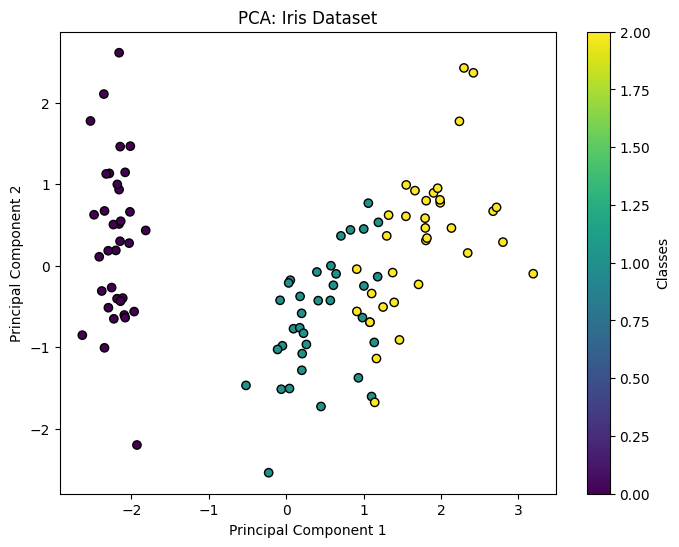

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='viridis', edgecolor='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: Iris Dataset')
plt.colorbar(label='Classes')
plt.show()


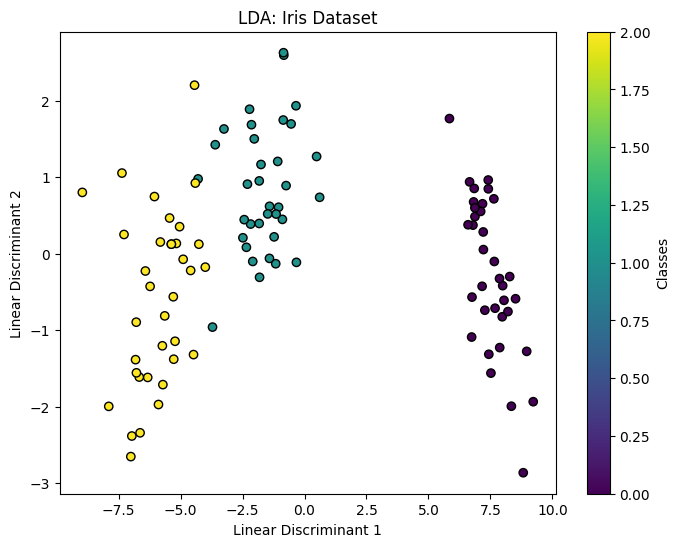

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(X_train_lda[:,0], X_train_lda[:,1], c=y_train, cmap='viridis', edgecolor='k')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.title('LDA: Iris Dataset')
plt.colorbar(label='Classes')
plt.show()


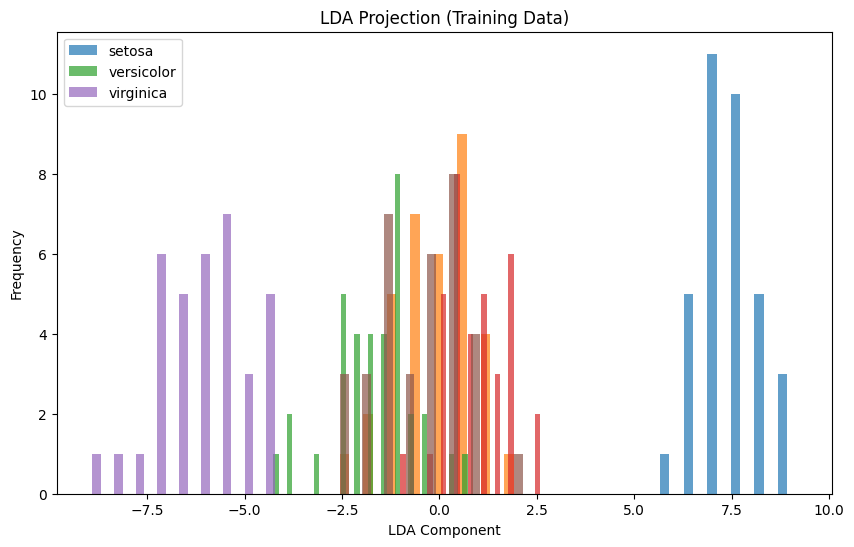

In [28]:
import matplotlib.pyplot as plt

class_labels = iris.target_names 

plt.figure(figsize=(10, 6))

for i, label in enumerate(class_labels):  
    plt.hist(X_train_lda[y_train == i], bins=20, alpha=0.7, label=label)

plt.title("LDA Projection (Training Data)")
plt.xlabel("LDA Component")
plt.ylabel("Frequency")
plt.legend()
plt.show()
